## Logistic Regression

In [12]:
##Load in Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, average_precision_score, precision_recall_curve
)

In [3]:
##Bring in the data
train_df = pd.read_csv('../data/processed/processed_train.csv')
test_df  = pd.read_csv('../data/processed/processed_test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (103904, 23)
Test shape:  (25976, 23)


,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,satisfaction,Total_Delay,Avg_Service_Rating
0,1,0,13,1,1,460,3,4,3,1,...,5,4,3,4,4,5,5,0,43.0,3.857143
1,1,1,25,0,2,235,3,2,3,3,...,1,1,5,3,1,4,1,0,7.0,2.285714
2,0,0,26,0,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,1,0.0,3.714286
3,0,0,25,0,2,562,2,5,5,5,...,2,2,5,3,1,4,2,0,20.0,3.000000
4,1,0,61,0,2,214,3,3,3,3,...,3,3,4,4,3,3,3,1,0.0,3.500000


In [4]:
## Target Split
TARGET = 'satisfaction'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print('Features:', X_train.columns.tolist())

Features: ['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Total_Delay', 'Avg_Service_Rating']


In [5]:
##Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [10]:
## K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1', 'average_precision'],
    return_train_score=True
)

print(f"CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"CV ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"CV F1 Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"CV PR-AUC:    {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")

CV Accuracy:  0.8748 ± 0.0024
CV ROC-AUC:   0.9264 ± 0.0018
CV F1 Score:  0.8526 ± 0.0028
CV PR-AUC:    0.9308 ± 0.0020


In [11]:
## Training the Final Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [13]:
## Apply MOdel to test set
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print(f'PR-AUC:   {average_precision_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Neutral/Dissatisfied', 'Satisfied']))

Accuracy: 0.8711
ROC-AUC:  0.9255
F1 Score: 0.8501
PR-AUC:   0.9306

                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.87      0.90      0.89     14573
           Satisfied       0.87      0.83      0.85     11403

            accuracy                           0.87     25976
           macro avg       0.87      0.87      0.87     25976
        weighted avg       0.87      0.87      0.87     25976



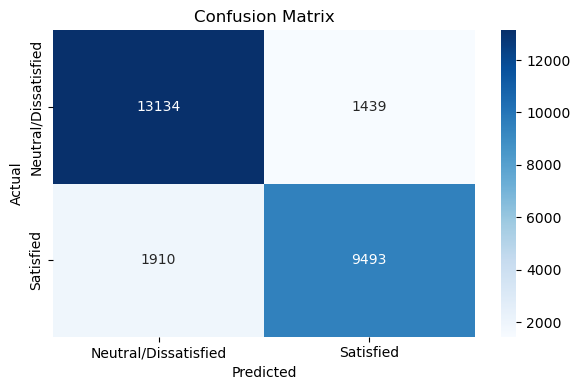

In [14]:
##COnfusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral/Dissatisfied', 'Satisfied'],
            yticklabels=['Neutral/Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

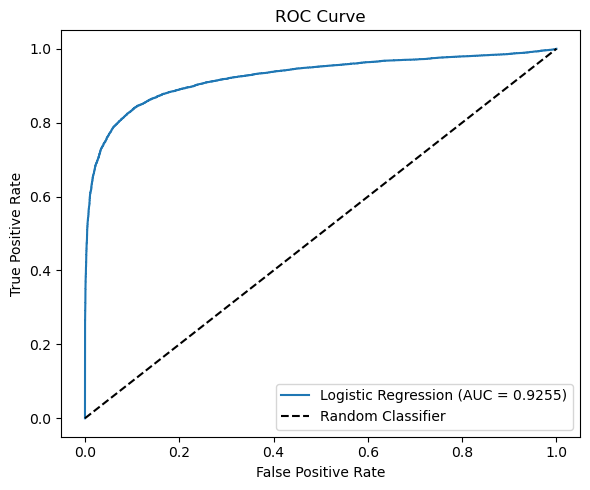

In [15]:
##ROC-Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

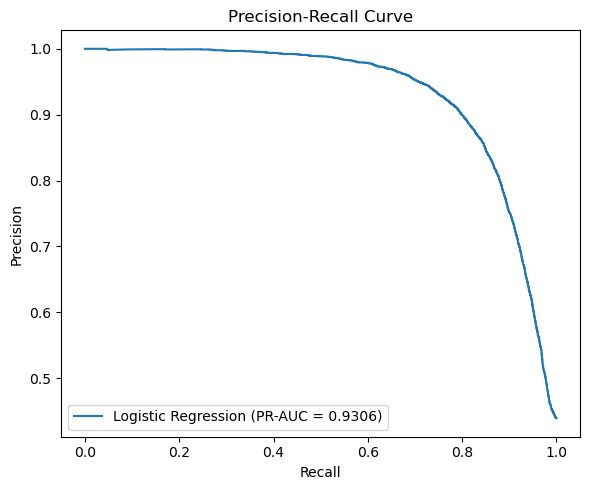

In [16]:
##Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

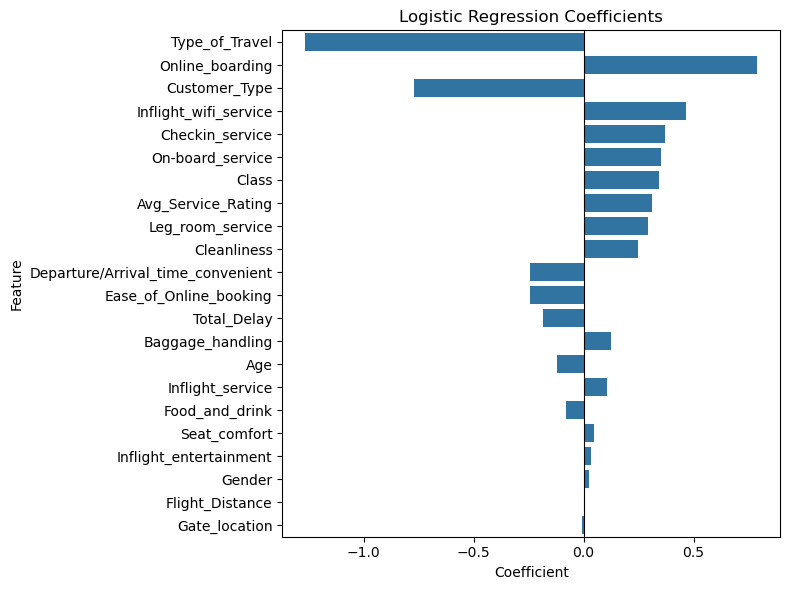

In [17]:
##Feature Importance
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()